# REINFORCE in TensorFlow (3 pts)

Just like we did before for Q-learning, this time we'll design a TensorFlow network to learn `CartPole-v0` via policy gradient (REINFORCE).

Most of the code in this notebook is taken from approximate Q-learning, so you'll find it more or less familiar and even simpler.

In [1]:
import sys, os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

A caveat: with some versions of `pyglet`, the following cell may crash with `NameError: name 'base' is not defined`. The corresponding bug report is [here](https://github.com/pyglet/pyglet/issues/134). If you see this error, try restarting the kernel.

/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


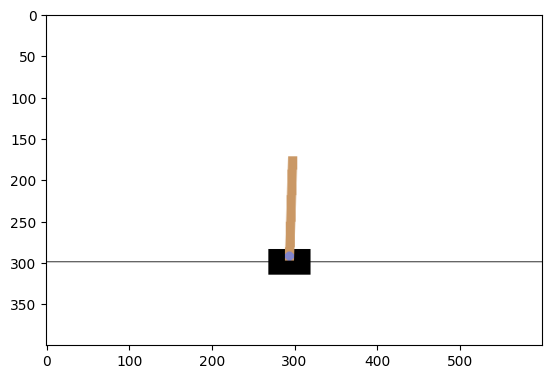

In [3]:
env = gym.make("CartPole-v0", render_mode="rgb_array").env  # unwrap TimeLimit

env.reset()
n_actions = int(env.action_space.n)
state_dim = tuple(int(x) for x in env.observation_space.shape)

plt.imshow(env.render())
env.close()

# Building the network for REINFORCE

For REINFORCE algorithm, we'll need a model that predicts action probabilities given states.

For numerical stability, please __do not include the softmax layer into your network architecture__.
We'll use softmax or log-softmax where appropriate.

In [4]:
# Switched the original TF1-graph notebook to TF 2.x eager mode.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
print("TF:", tf.__version__)

TF: 2.21.0


In [5]:
# In eager mode there are no placeholders; we'll feed concrete tensors to a tf.function below.
pass

In [6]:
model = keras.Sequential([
    L.Input(shape=state_dim),
    L.Dense(128, activation='relu'),
    L.Dense(128, activation='relu'),
    L.Dense(n_actions),  # logits, no softmax
])
model.summary()

E0000 00:00:1778364446.375664  352622 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,410 (68.01 KB)

 Trainable params: 17,410 (68.01 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# (Keras initializes the weights eagerly when the layers are first called.)
pass

In [8]:
def predict_probs(states):
    """
    Predict action probabilities for a single state (1D vector).
    :returns: numpy array of shape [n_actions]
    """
    states = np.asarray(states, dtype=np.float32)[None]
    logits = model(states)
    return tf.nn.softmax(logits, axis=-1).numpy()[0]

### Play the game

We can now use our newly built agent to play the game.

In [9]:
def generate_session(env, t_max=1000):
    """Play a full session with the REINFORCE agent."""
    states, actions, rewards = [], [], []
    s, _ = env.reset()

    for t in range(t_max):
        action_probs = predict_probs(s)
        a = int(np.random.choice(n_actions, p=action_probs))
        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s); actions.append(a); rewards.append(r)
        s = new_s
        if terminated or truncated:
            break

    return states, actions, rewards

In [10]:
# test it
states, actions, rewards = generate_session(env)

### Computing cumulative rewards

$$
\begin{align*}
G_t &= r_t + \gamma r_{t + 1} + \gamma^2 r_{t + 2} + \ldots \\
&= \sum_{i = t}^T \gamma^{i - t} r_i \\
&= r_t + \gamma * G_{t + 1}
\end{align*}
$$

In [11]:
def get_cumulative_rewards(rewards,  # rewards at each step
                           gamma=0.99  # discount for reward
                           ):
    """
    Take a list of immediate rewards r(s,a) for the whole session 
    and compute cumulative returns (a.k.a. G(s,a) in Sutton '16).
    
    G_t = r_t + gamma*r_{t+1} + gamma^2*r_{t+2} + ...

    A simple way to compute cumulative rewards is to iterate from the last
    to the first timestep and compute G_t = r_t + gamma*G_{t+1} recurrently

    You must return an array/list of cumulative rewards with as many elements as in the initial rewards.
    """
    G = [0.0] * len(rewards)
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G

In [12]:
assert len(get_cumulative_rewards(range(100))) == 100
assert np.allclose(
    get_cumulative_rewards([0, 0, 1, 0, 0, 1, 0], gamma=0.9),
    [1.40049, 1.5561, 1.729, 0.81, 0.9, 1.0, 0.0])
assert np.allclose(
    get_cumulative_rewards([0, 0, 1, -2, 3, -4, 0], gamma=0.5),
    [0.0625, 0.125, 0.25, -1.5, 1.0, -4.0, 0.0])
assert np.allclose(
    get_cumulative_rewards([0, 0, 1, 2, 3, 4, 0], gamma=0),
    [0, 0, 1, 2, 3, 4, 0])
print("looks good!")

looks good!


#### Loss function and updates

We now need to define objective and update over policy gradient.

Our objective function is

$$ J \approx  { 1 \over N } \sum_{s_i,a_i} G(s_i,a_i) $$

REINFORCE defines a way to compute the gradient of the expected reward with respect to policy parameters. The formula is as follows:

$$ \nabla_\theta \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \nabla_\theta \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

We can abuse Tensorflow's capabilities for automatic differentiation by defining our objective function as follows:

$$ \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

When you compute the gradient of that function with respect to network weights $\theta$, it will become exactly the policy gradient.

In [13]:
# In eager mode the logits / log_policy / log_pi(a|s) are all built inside the
# train_on_session tf.function below, so this cell is a no-op.
pass

In [14]:
# Policy objective as in the last formula. Please use reduce_mean, not reduce_sum.
# You may use log_policy_for_actions to get log probabilities for actions taken.
# Also recall that we defined ph_cumulative_rewards earlier.

# Eager: J is computed inside the tf.function below as
#     J = mean( log_pi(a_i | s_i) * G_i ).
pass

As a reminder, for a discrete probability distribution (like the one our policy outputs), entropy is defined as:

$$ \operatorname{entropy}(p) = -\sum_{i = 1}^n p_i \cdot \log p_i $$

In [15]:
# Entropy regularization. If you don't add it, the policy will quickly deteriorate to
# being deterministic, harming exploration.

# Eager: entropy is computed inside the tf.function below as
#     -sum(p * log_p) per sample, then averaged.
pass

In [16]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)


@tf.function
def reinforce_step(states, actions, returns, entropy_coef=0.1):
    with tf.GradientTape() as tape:
        logits = model(states)
        log_probs = tf.nn.log_softmax(logits, axis=-1)
        probs = tf.nn.softmax(logits, axis=-1)
        log_pi_a = tf.reduce_sum(log_probs * tf.one_hot(actions, n_actions), axis=-1)
        J = tf.reduce_mean(log_pi_a * returns)
        entropy = -tf.reduce_mean(tf.reduce_sum(probs * log_probs, axis=-1))
        loss = -(J + entropy_coef * entropy)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

In [17]:
def train_on_session(states, actions, rewards, t_max=1000):
    cumulative_rewards = get_cumulative_rewards(rewards)
    reinforce_step(
        tf.constant(np.asarray(states, dtype=np.float32)),
        tf.constant(np.asarray(actions, dtype=np.int32)),
        tf.constant(np.asarray(cumulative_rewards, dtype=np.float32)),
    )
    return sum(rewards)

In [18]:
# Eager Keras: optimizer state is built lazily on the first apply_gradients.
pass

### The actual training

In [19]:
env = gym.make("CartPole-v0", render_mode="rgb_array").env  # uncapped CartPole-v0
for i in range(60):
    rewards = [train_on_session(*generate_session(env)) for _ in range(50)]
    print("epoch #%d  mean reward: %.3f" % (i, np.mean(rewards)))
    if np.mean(rewards) > 300:
        print("Solved!"); break

/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


epoch #0  mean reward: 47.640


epoch #1  mean reward: 68.560


epoch #2  mean reward: 66.760


epoch #3  mean reward: 181.560


epoch #4  mean reward: 101.600


epoch #5  mean reward: 134.680


epoch #6  mean reward: 470.300
Solved!


### Results & video

In [20]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with gym.make("CartPole-v0", render_mode="rgb_array") as env, RecordVideo(env=env, video_folder="./videos_tf") as env_monitor:
    sessions = [generate_session(env_monitor) for _ in range(3)]
print("eval session lengths:", [len(s[0]) for s in sessions])

eval session lengths: [200, 200, 146]


In [21]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
video_paths = sorted([s for s in Path('videos_tf').iterdir() if s.suffix == '.mp4']) if Path('videos_tf').exists() else []
print(f"recorded {len(video_paths)} mp4(s)")
for p in video_paths[:3]: print(' -', p)

recorded 2 mp4(s)
 - videos_tf/rl-video-episode-0.mp4
 - videos_tf/rl-video-episode-1.mp4
